In [1]:
import pandas as pd 
import json 
import numpy as np
from pathlib import Path
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from openTSNE import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm 
import math
import sys
sys.path.insert(0, '..')  # run from nbs/

from src_4u2.model_dev.factor_recsys import one_hot_encode_df, svd_genres, embed_new_events
from src_4u2.model_dev.evaluation import get_user_representation, generate_reclist, evaluate

DATA_DIR = "../data/model_training_data/"

ImportError: cannot import name 'one_hot_encode_df' from 'src_4u2.model_dev.factor_recsys' (/Users/cmbcss/repos/ra-fetcher-nextloc/nbs/../src_4u2/model_dev/factor_recsys.py)

In [ ]:
# load train data 
train = pd.read_csv(DATA_DIR + "event_train", index_col=0)
train['genres'] = train['genres'].apply(ast.literal_eval)
train = train[train['genres'].apply(len) > 0] 
train = train.set_index('id')

test = pd.read_csv(DATA_DIR + "event_test", index_col=0)
test['genres'] = test['genres'].apply(ast.literal_eval)
test = test[test['genres'].apply(len) > 0] 
test = test.set_index('id')

In [ ]:
# load eval data
with open(DATA_DIR+'artist_eval_data.json') as f:
    artist_eval_data = json.load(f)

ImportError: cannot import name 'svd_genres' from 'src_4u2.model_dev.factor_recsys' (/Users/cmbcss/repos/ra-fetcher-nextloc/nbs/../src_4u2/model_dev/factor_recsys.py)

In [103]:
embedding_train, svd_model, onehot_encoder = svd_genres(train)
embedding_test = embed_new_events(test, svd_model, onehot_encoder)
global_embedding = pd.concat([embedding_test, embedding_train])

In [141]:
len(global_embedding)

140697

In [104]:
M = global_embedding.values
event2embedding_id = {eid:i for i, eid in enumerate(list(global_embedding.index))}

In [142]:
len(M)

140697

### Evaluate the embedding

In [ ]:
event_ids = list(event2embedding_id.keys()) # same order as embedding matrix

In [ ]:


N_TEST = 100

results_ndcg = []
results_pos = []

for aid in tqdm(list(artist_eval_data.keys())[:N_TEST]):
    past_event_hist = artist_eval_data[aid]['train_eids']
    future_events = artist_eval_data[aid]['test_eids'][0] # just get the first for now

    # i.e. if we have have not deleted this event since has no genre
    if future_events in event_ids:
        user_rep = get_user_representation(M, event2embedding_id, past_event_hist)

        # i.e. if we are able to assign some points to a users past history 
        if len(user_rep) > 0:
            ndcg, pos = evaluate(user_rep=user_rep, embedding=M, all_event_ids=event_ids, query_eid=future_events)
            results_ndcg.append(ndcg)
            results_pos.append(pos)

100%|██████████| 100/100 [15:12<00:00,  9.12s/it]


In [138]:
print(f"avg ndcg: {np.mean(results_ndcg)}")
print(f"pos {np.mean(results_pos)} out of {len(M)}")

avg ndcg: 0.07978216203815698
pos 30895.95348837209 out of 140697


In [124]:
future_events[0] in event_ids

True

position 6173 out of 140697
NDCG: 0.07941556643985394


In [108]:
past_event_hist[:4]

[2129595, 2166914, 2189888, 2237931]

In [ ]:
for eid in past_event_hist:
    try:
        #print(embedding_train.loc[eid])
        event2embedding_id[eid])
    except:
        print('event with no genre')

60238
61635
69132
event with no genre
114605
event with no genre
134594
138986
140047


event w/ no genre
event w/ no genre


/opt/anaconda3/envs/RA-scraper_conda/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/RA-scraper_conda/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan

### Visualise the embedding

In [ ]:
sample = genre_embeddings_df.sample(1000, random_state=42)
X_2d = TSNE(n_components=2, random_state=42).fit(sample.values)

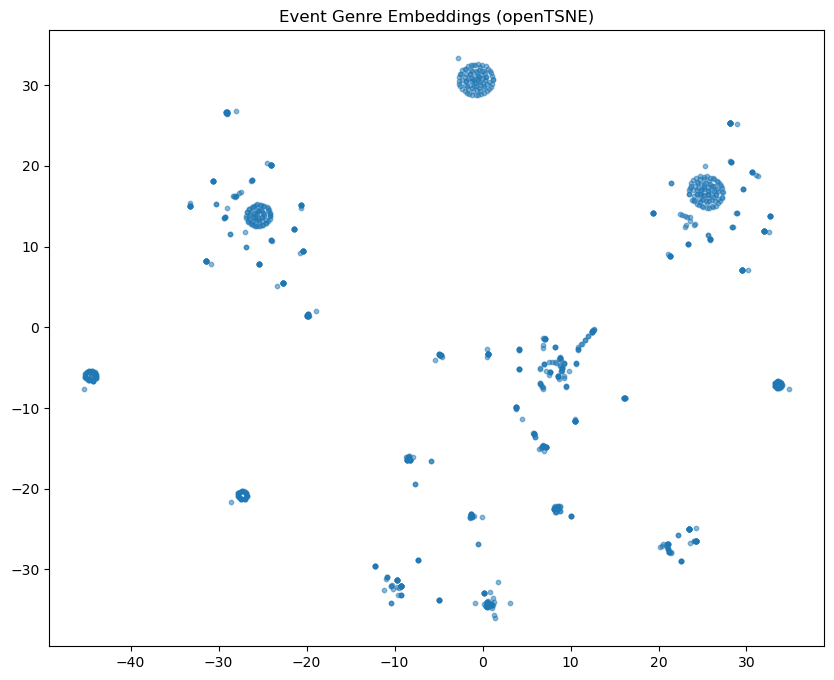

In [12]:
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10)
plt.title("Event Genre Embeddings (openTSNE)")
plt.show()

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_2d = TSNE(n_components=2, random_state=42).fit_transform(genre_embeddings_df.values)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10)
plt.title("Event Genre Embeddings (t-SNE)")
plt.show()

KeyboardInterrupt: 

In [ ]:
import pacmap
import matplotlib.pyplot as plt

embedding = pacmap.PaCMAP(n_components=2)
X_2d = embedding.fit_transform(genre_embeddings_df.values)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10)
plt.title("Event Genre Embeddings (PaCMAP)")
plt.show()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [26]:
components_df = pd.DataFrame(
    svd.components_,
    columns=mlb.classes_,
    index=[f'dim_{i}' for i in range(10)]
)

for dim in components_df.index:
    top = components_df.loc[dim].nlargest(4)
    bottom = components_df.loc[dim].nsmallest(4)
    print(f"\n{dim}:")
    for genre, weight in top.items():
        print(f"  {genre}: {weight:.3f}")
    print("  ---")
    for genre, weight in bottom.items():
        print(f"  {genre}: {weight:.3f}")



dim_0:
  House: 0.782
  Techno: 0.598
  Tech House: 0.109
  Disco: 0.075
  ---
  Drill: 0.000
  Singeli: 0.000
  Kuduro: 0.000
  Kwaito: 0.000

dim_1:
  Techno: 0.791
  Trance: 0.083
  Industrial: 0.032
  Hardcore: 0.023
  ---
  House: -0.589
  Disco: -0.103
  Tech House: -0.054
  Deep House: -0.051

dim_2:
  Tech House: 0.977
  Minimal: 0.087
  Deep House: 0.064
  Afro House: 0.045
  ---
  Disco: -0.127
  House: -0.113
  Techno: -0.024
  Electro: -0.021

dim_3:
  Electronica: 0.944
  Experimental: 0.207
  Club: 0.158
  Electro: 0.101
  ---
  House: -0.036
  Disco: -0.034
  Techno: -0.033
  Trance: -0.024

dim_4:
  Disco: 0.963
  Funk / Soul: 0.140
  Tech House: 0.114
  Pop: 0.058
  ---
  House: -0.132
  Electro: -0.101
  Minimal: -0.036
  Garage: -0.029

dim_5:
  Deep House: 0.942
  Afro House: 0.233
  Progressive House: 0.079
  Minimal: 0.039
  ---
  Electro: -0.148
  Tech House: -0.090
  Club: -0.078
  Electronica: -0.061

dim_6:
  Electro: 0.942
  Deep House: 0.153
  Club: 0.150
 